In [ ]:
# ==============================================
# IMPORT LIBRARIES
# ==============================================

# Data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)
import xgboost as xgb
import joblib
from tabulate import tabulate

# Other utilities
from datetime import datetime
import warnings

# ==============================================
# CONFIGURATION
# ==============================================

# Set random seed for reproducibility
np.random.seed(42)

# Visualization settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
palette = sns.color_palette("husl", 8)

# Suppress warnings
warnings.filterwarnings('ignore')

In [ ]:
# ==============================================
# LOAD DATA
# ==============================================

base = "/kaggle/input/mimic-iii-10k/MIMIC -III (10000 patients)/"
diagnoses_df  = pd.read_csv(base + "DIAGNOSES_ICD/DIAGNOSES_ICD_random.csv")
procedures_df = pd.read_csv(base + "PROCEDURES_ICD/PROCEDURES_ICD_random.csv")
icustays_df   = pd.read_csv(base + "ICUSTAYS/ICUSTAYS_random.csv")
labevents_df  = pd.read_csv(base + "LABEVENTS/LABEVENTS_random.csv")
labitems_df   = pd.read_csv(base + "D_LABITEMS/D_LABITEMS.csv")
admissions_df = pd.read_csv(base + "ADMISSIONS/ADMISSIONS_random.csv")
patients_df   = pd.read_csv(base + "PATIENTS/PATIENTS_random.csv")

diab_df = pd.read_csv("/kaggle/input/diabetes/diabetic_data.csv")

# Print column names
print("DIAGNOSES columns:      ", diagnoses_df.columns.tolist())
print("D_LABITEMS columns:         ", labitems_df.columns.tolist())
print("ADMISSIONS columns:         ", admissions_df.columns.tolist())
print("PATIENTS columns:           ", patients_df.columns.tolist())
print("PROCEDURES columns:     ", procedures_df.columns.tolist())
print("ICUSTAYS columns:           ", icustays_df.columns.tolist())
print("LABEVENTS columns:          ", labevents_df.columns.tolist())
print("DIABETES columns:          ", diab_df.columns.tolist())

DIAGNOSES columns:       ['ROW_ID', 'SUBJECT_ID', 'HADM_ID', 'SEQ_NUM', 'ICD9_CODE']
D_LABITEMS columns:          ['ROW_ID', 'ITEMID', 'LABEL', 'FLUID', 'CATEGORY', 'LOINC_CODE']
ADMISSIONS columns:          ['ROW_ID', 'SUBJECT_ID', 'HADM_ID', 'ADMITTIME', 'DISCHTIME', 'DEATHTIME', 'ADMISSION_TYPE', 'ADMISSION_LOCATION', 'DISCHARGE_LOCATION', 'INSURANCE', 'LANGUAGE', 'RELIGION', 'MARITAL_STATUS', 'ETHNICITY', 'EDREGTIME', 'EDOUTTIME', 'DIAGNOSIS', 'HOSPITAL_EXPIRE_FLAG', 'HAS_CHARTEVENTS_DATA']
PATIENTS columns:            ['ROW_ID', 'SUBJECT_ID', 'GENDER', 'DOB', 'DOD', 'DOD_HOSP', 'DOD_SSN', 'EXPIRE_FLAG']
PROCEDURES columns:      ['ROW_ID', 'SUBJECT_ID', 'HADM_ID', 'SEQ_NUM', 'ICD9_CODE']
ICUSTAYS columns:            ['ROW_ID', 'SUBJECT_ID', 'HADM_ID', 'ICUSTAY_ID', 'DBSOURCE', 'FIRST_CAREUNIT', 'LAST_CAREUNIT', 'FIRST_WARDID', 'LAST_WARDID', 'INTIME', 'OUTTIME', 'LOS']
LABEVENTS columns:           ['ROW_ID', 'SUBJECT_ID', 'HADM_ID', 'ITEMID', 'CHARTTIME', 'VALUE', 'VALUENUM', 'VALU

In [ ]:
## ==============================================
# INITIAL INSPECTION
# ==============================================

def load_and_inspect_data():
    """Load datasets and perform initial inspection"""
    print("⏳ Loading datasets...")

    # Load MIMIC data
    base_path = "/kaggle/input/mimic-iii-10k/MIMIC -III (10000 patients)/"
    mimic_files = {
        'diagnoses': "DIAGNOSES_ICD/DIAGNOSES_ICD_random.csv",
        'procedures': "PROCEDURES_ICD/PROCEDURES_ICD_random.csv",
        'icustays': "ICUSTAYS/ICUSTAYS_random.csv",
        'labevents': "LABEVENTS/LABEVENTS_random.csv",
        'labitems': "D_LABITEMS/D_LABITEMS.csv",
        'admissions': "ADMISSIONS/ADMISSIONS_random.csv",
        'patients': "PATIENTS/PATIENTS_random.csv"
    }

    mimic_data = {}
    for name, path in mimic_files.items():
        mimic_data[name] = pd.read_csv(base_path + path)

    # Load diabetic data
    diab_data = pd.read_csv("/kaggle/input/diabetes/diabetic_data.csv")

    # Initial data inspection
    print("\n🔍 Dataset Shapes:")
    for name, df in mimic_data.items():
        print(f"{name.upper():<12} {df.shape}")
    print(f"DIABETIC_DATA {diab_data.shape}")

    return mimic_data, diab_data

mimic_data, diab_data = load_and_inspect_data()

⏳ Loading datasets...

🔍 Dataset Shapes:
DIAGNOSES    (140502, 5)
PROCEDURES   (57401, 5)
ICUSTAYS     (13485, 12)
LABEVENTS    (6089629, 9)
LABITEMS     (753, 6)
ADMISSIONS   (12537, 19)
PATIENTS     (10000, 8)
DIABETIC_DATA (101766, 50)



📊 TARGET VARIABLE ANALYSIS


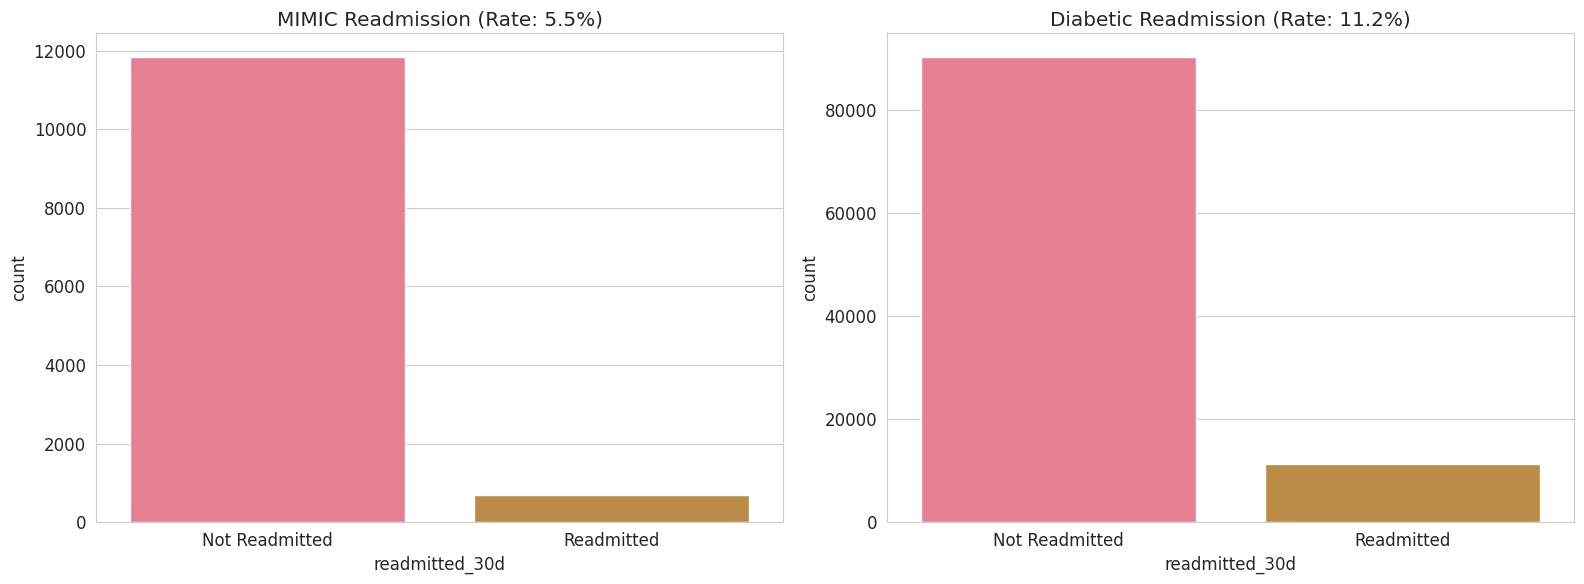

In [ ]:
# ==============================================
# TARGET VARIABLE ANALYSIS
# ==============================================

def analyze_target_variables(admissions_df, diab_df):
    """Analyze readmission rates in both datasets"""
    print("\n📊 TARGET VARIABLE ANALYSIS")

    # MIMIC readmission calculation
    admissions_df['ADMITTIME'] = pd.to_datetime(admissions_df['ADMITTIME'])
    admissions_df['DISCHTIME'] = pd.to_datetime(admissions_df['DISCHTIME'])
    admissions_df = admissions_df.sort_values(['SUBJECT_ID','ADMITTIME'])

    admissions_df['next_ADMIT'] = admissions_df.groupby('SUBJECT_ID')['ADMITTIME'].shift(-1)
    admissions_df['days_to_next'] = (admissions_df['next_ADMIT'] - admissions_df['DISCHTIME']).dt.total_seconds()/(24*3600)
    admissions_df['readmitted_30d'] = ((admissions_df['days_to_next'] > 0) &
                                     (admissions_df['days_to_next'] <= 30)).astype(int)

    # Diabetic data readmission
    diab_df['readmitted_30d'] = (diab_df['readmitted'] == '<30').astype(int)

    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # MIMIC readmission
    mimic_readmit_rate = admissions_df['readmitted_30d'].mean()
    sns.countplot(x='readmitted_30d', data=admissions_df, ax=ax1, palette=palette)
    ax1.set_title(f'MIMIC Readmission (Rate: {mimic_readmit_rate:.1%})')
    ax1.set_xticklabels(['Not Readmitted', 'Readmitted'])

    # Diabetic readmission
    diab_readmit_rate = diab_df['readmitted_30d'].mean()
    sns.countplot(x='readmitted_30d', data=diab_df, ax=ax2, palette=palette)
    ax2.set_title(f'Diabetic Readmission (Rate: {diab_readmit_rate:.1%})')
    ax2.set_xticklabels(['Not Readmitted', 'Readmitted'])

    plt.tight_layout()
    plt.show()

    return admissions_df, diab_df

mimic_data['admissions'], diab_data = analyze_target_variables(
    mimic_data['admissions'], diab_data
)


⏳ TEMPORAL FEATURE ANALYSIS


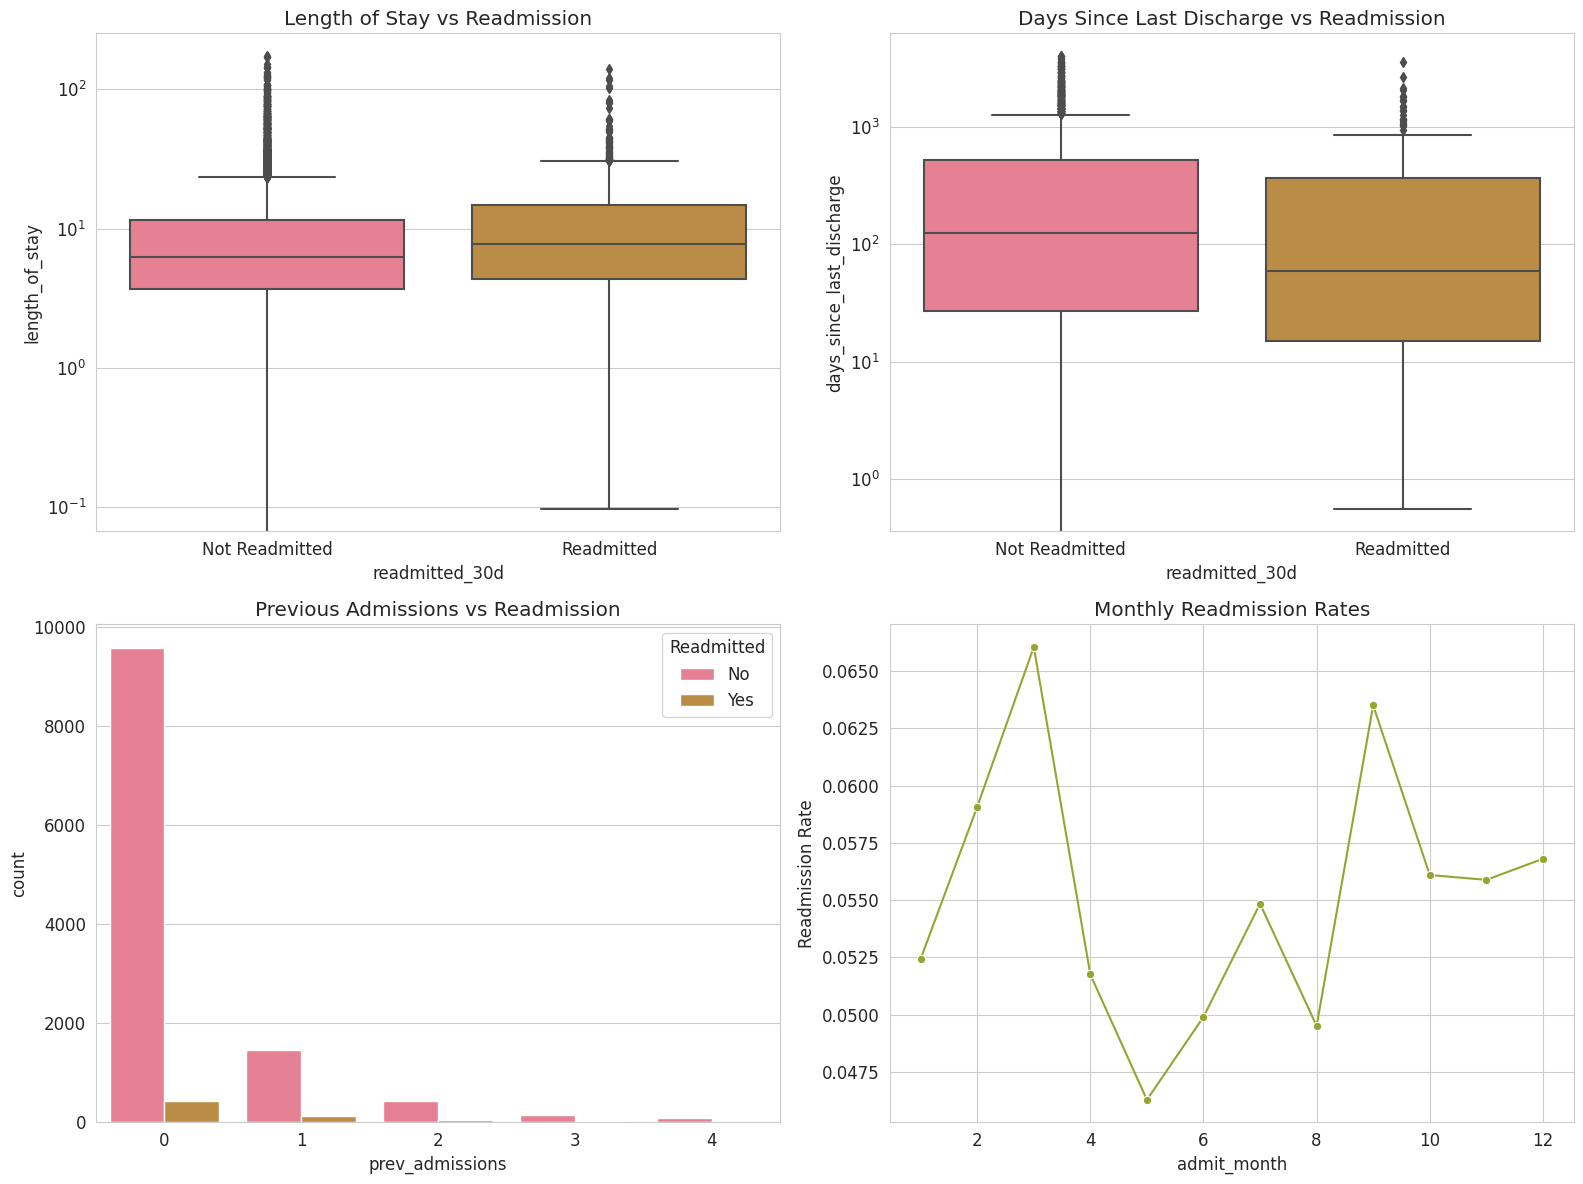

In [ ]:
# ==============================================
# TEMPORAL FEATURE ANALYSIS
# ==============================================

def analyze_temporal_features(admissions_df):
    """Analyze temporal patterns in readmissions"""
    print("\n⏳ TEMPORAL FEATURE ANALYSIS")

    # Calculate length of stay
    admissions_df['length_of_stay'] = (admissions_df['DISCHTIME'] - admissions_df['ADMITTIME']).dt.total_seconds()/(24*3600)

    # Previous admissions
    admissions_df['prev_admissions'] = admissions_df.groupby('SUBJECT_ID').cumcount()
    admissions_df['prev_DISCH'] = admissions_df.groupby('SUBJECT_ID')['DISCHTIME'].shift(1)
    admissions_df['days_since_last_discharge'] = (admissions_df['ADMITTIME'] - admissions_df['prev_DISCH']).dt.total_seconds()/(24*3600)

    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Length of stay
    sns.boxplot(x='readmitted_30d', y='length_of_stay', data=admissions_df, ax=axes[0,0], palette=palette)
    axes[0,0].set_title('Length of Stay vs Readmission')
    axes[0,0].set_xticklabels(['Not Readmitted', 'Readmitted'])
    axes[0,0].set_yscale('log')

    # Days since last discharge
    sns.boxplot(x='readmitted_30d', y='days_since_last_discharge',
                data=admissions_df[admissions_df['days_since_last_discharge'].notna()],
                ax=axes[0,1], palette=palette)
    axes[0,1].set_title('Days Since Last Discharge vs Readmission')
    axes[0,1].set_xticklabels(['Not Readmitted', 'Readmitted'])
    axes[0,1].set_yscale('log')

    # Previous admissions
    sns.countplot(x='prev_admissions', hue='readmitted_30d',
                 data=admissions_df[admissions_df['prev_admissions'] < 5],
                 ax=axes[1,0], palette=palette)
    axes[1,0].set_title('Previous Admissions vs Readmission')
    axes[1,0].legend(title='Readmitted', labels=['No', 'Yes'])

    # Admission month
    admissions_df['admit_month'] = admissions_df['ADMITTIME'].dt.month
    monthly_readmit = admissions_df.groupby('admit_month')['readmitted_30d'].mean().reset_index()
    sns.lineplot(x='admit_month', y='readmitted_30d', data=monthly_readmit,
                ax=axes[1,1], marker='o', color=palette[2])
    axes[1,1].set_title('Monthly Readmission Rates')
    axes[1,1].set_ylabel('Readmission Rate')

    plt.tight_layout()
    plt.show()

    return admissions_df

mimic_data['admissions'] = analyze_temporal_features(mimic_data['admissions'])



🏥 CLINICAL ACTIVITY ANALYSIS


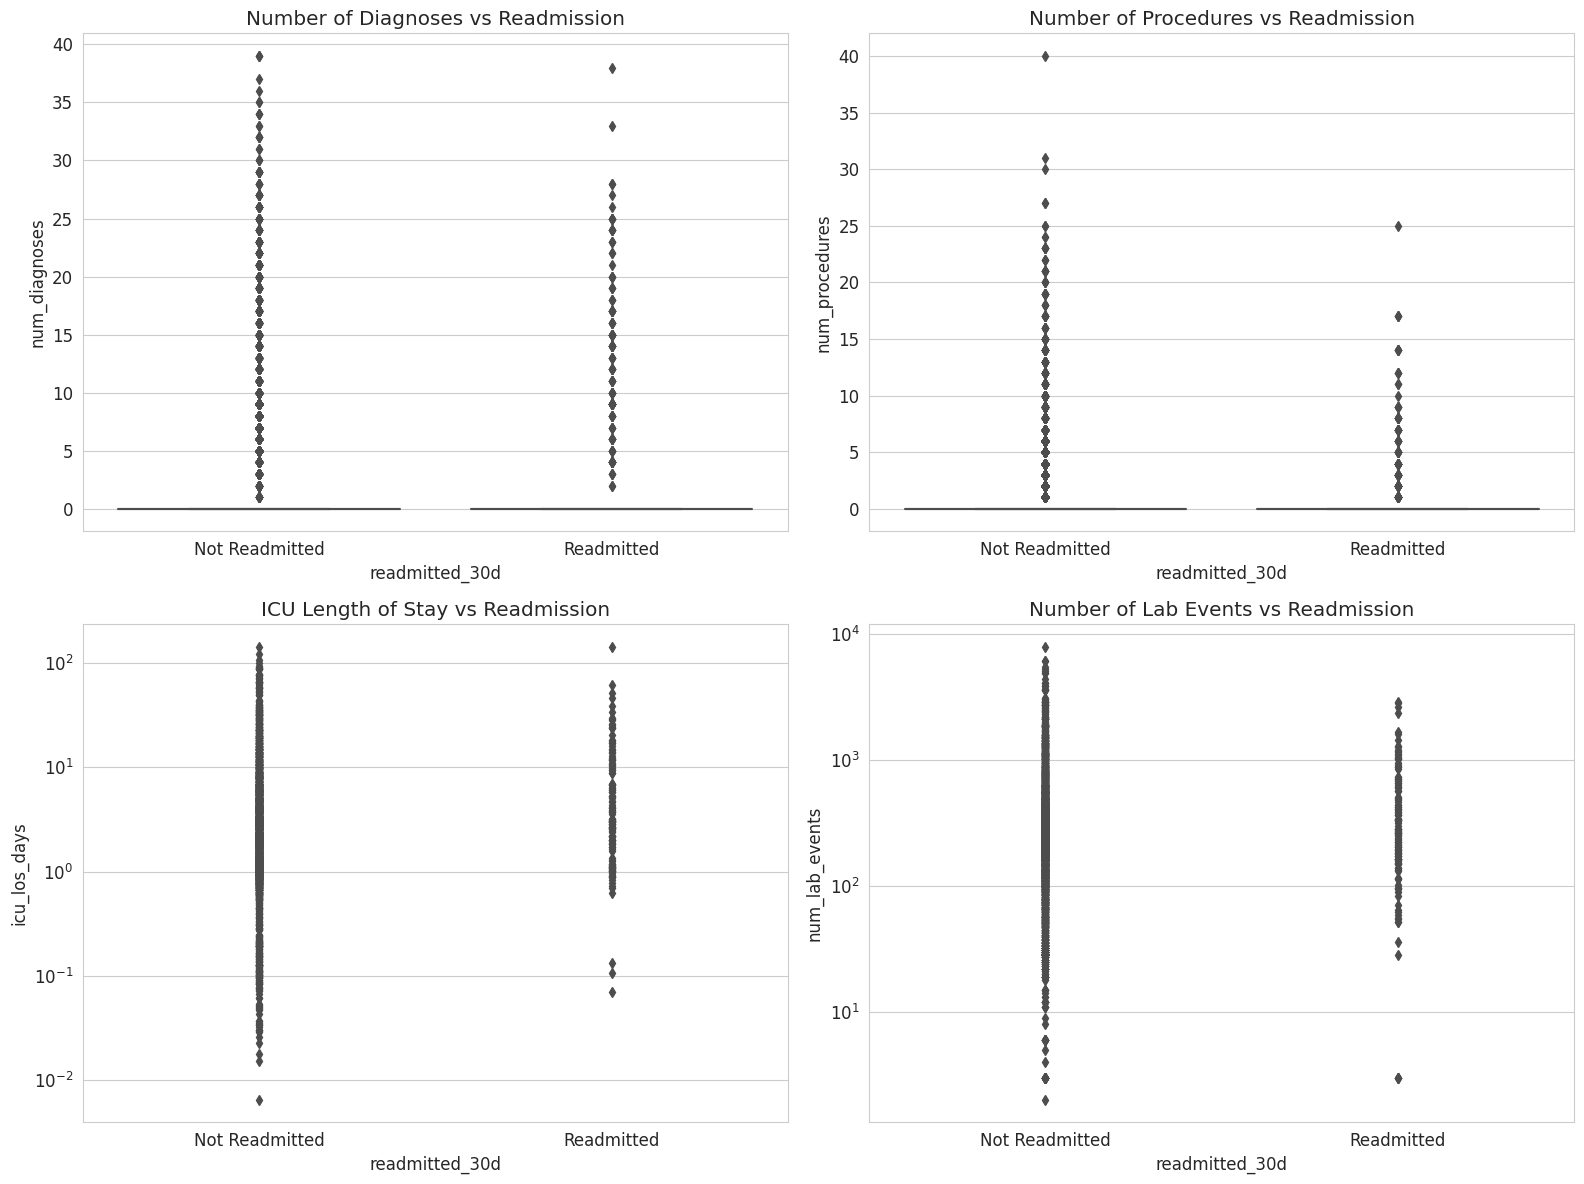

In [ ]:
# ==============================================
# CLINICAL ACTIVITY ANALYSIS
# ==============================================

def analyze_clinical_activity(mimic_data):
    """Analyze clinical activity patterns"""
    print("\n🏥 CLINICAL ACTIVITY ANALYSIS")

    # Merge diagnosis counts
    diag_counts = (mimic_data['diagnoses']
                  .groupby(['SUBJECT_ID','HADM_ID'])
                  .size()
                  .rename('num_diagnoses')
                  .reset_index())

    # Merge procedure counts
    proc_counts = (mimic_data['procedures']
                  .groupby(['SUBJECT_ID','HADM_ID'])
                  .size()
                  .rename('num_procedures')
                  .reset_index())

    # Merge ICU stays
    icu_agg = (mimic_data['icustays']
              .groupby(['SUBJECT_ID','HADM_ID'])['LOS']
              .sum()
              .rename('icu_los_days')
              .reset_index())

    # Merge lab events
    mimic_data['labevents']['VALUENUM'] = pd.to_numeric(mimic_data['labevents']['VALUENUM'], errors='coerce')
    lab_counts = (mimic_data['labevents']
                 .groupby(['SUBJECT_ID','HADM_ID'])
                 .size()
                 .rename('num_lab_events')
                 .reset_index())

    # Merge with admissions
    admissions_df = mimic_data['admissions']
    admissions_df = (admissions_df
                    .merge(diag_counts, on=['SUBJECT_ID','HADM_ID'], how='left')
                    .merge(proc_counts, on=['SUBJECT_ID','HADM_ID'], how='left')
                    .merge(icu_agg, on=['SUBJECT_ID','HADM_ID'], how='left')
                    .merge(lab_counts, on=['SUBJECT_ID','HADM_ID'], how='left')
                    .fillna({'num_diagnoses': 0, 'num_procedures': 0,
                            'icu_los_days': 0, 'num_lab_events': 0}))

    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Number of diagnoses
    sns.boxplot(x='readmitted_30d', y='num_diagnoses',
               data=admissions_df, ax=axes[0,0], palette=palette)
    axes[0,0].set_title('Number of Diagnoses vs Readmission')
    axes[0,0].set_xticklabels(['Not Readmitted', 'Readmitted'])

    # Number of procedures
    sns.boxplot(x='readmitted_30d', y='num_procedures',
               data=admissions_df, ax=axes[0,1], palette=palette)
    axes[0,1].set_title('Number of Procedures vs Readmission')
    axes[0,1].set_xticklabels(['Not Readmitted', 'Readmitted'])

    # ICU length of stay
    sns.boxplot(x='readmitted_30d', y='icu_los_days',
               data=admissions_df, ax=axes[1,0], palette=palette)
    axes[1,0].set_title('ICU Length of Stay vs Readmission')
    axes[1,0].set_xticklabels(['Not Readmitted', 'Readmitted'])
    axes[1,0].set_yscale('log')

    # Number of lab events
    sns.boxplot(x='readmitted_30d', y='num_lab_events',
               data=admissions_df, ax=axes[1,1], palette=palette)
    axes[1,1].set_title('Number of Lab Events vs Readmission')
    axes[1,1].set_xticklabels(['Not Readmitted', 'Readmitted'])
    axes[1,1].set_yscale('log')

    plt.tight_layout()
    plt.show()

    return admissions_df

mimic_data['admissions'] = analyze_clinical_activity(mimic_data)



👥 DEMOGRAPHIC ANALYSIS


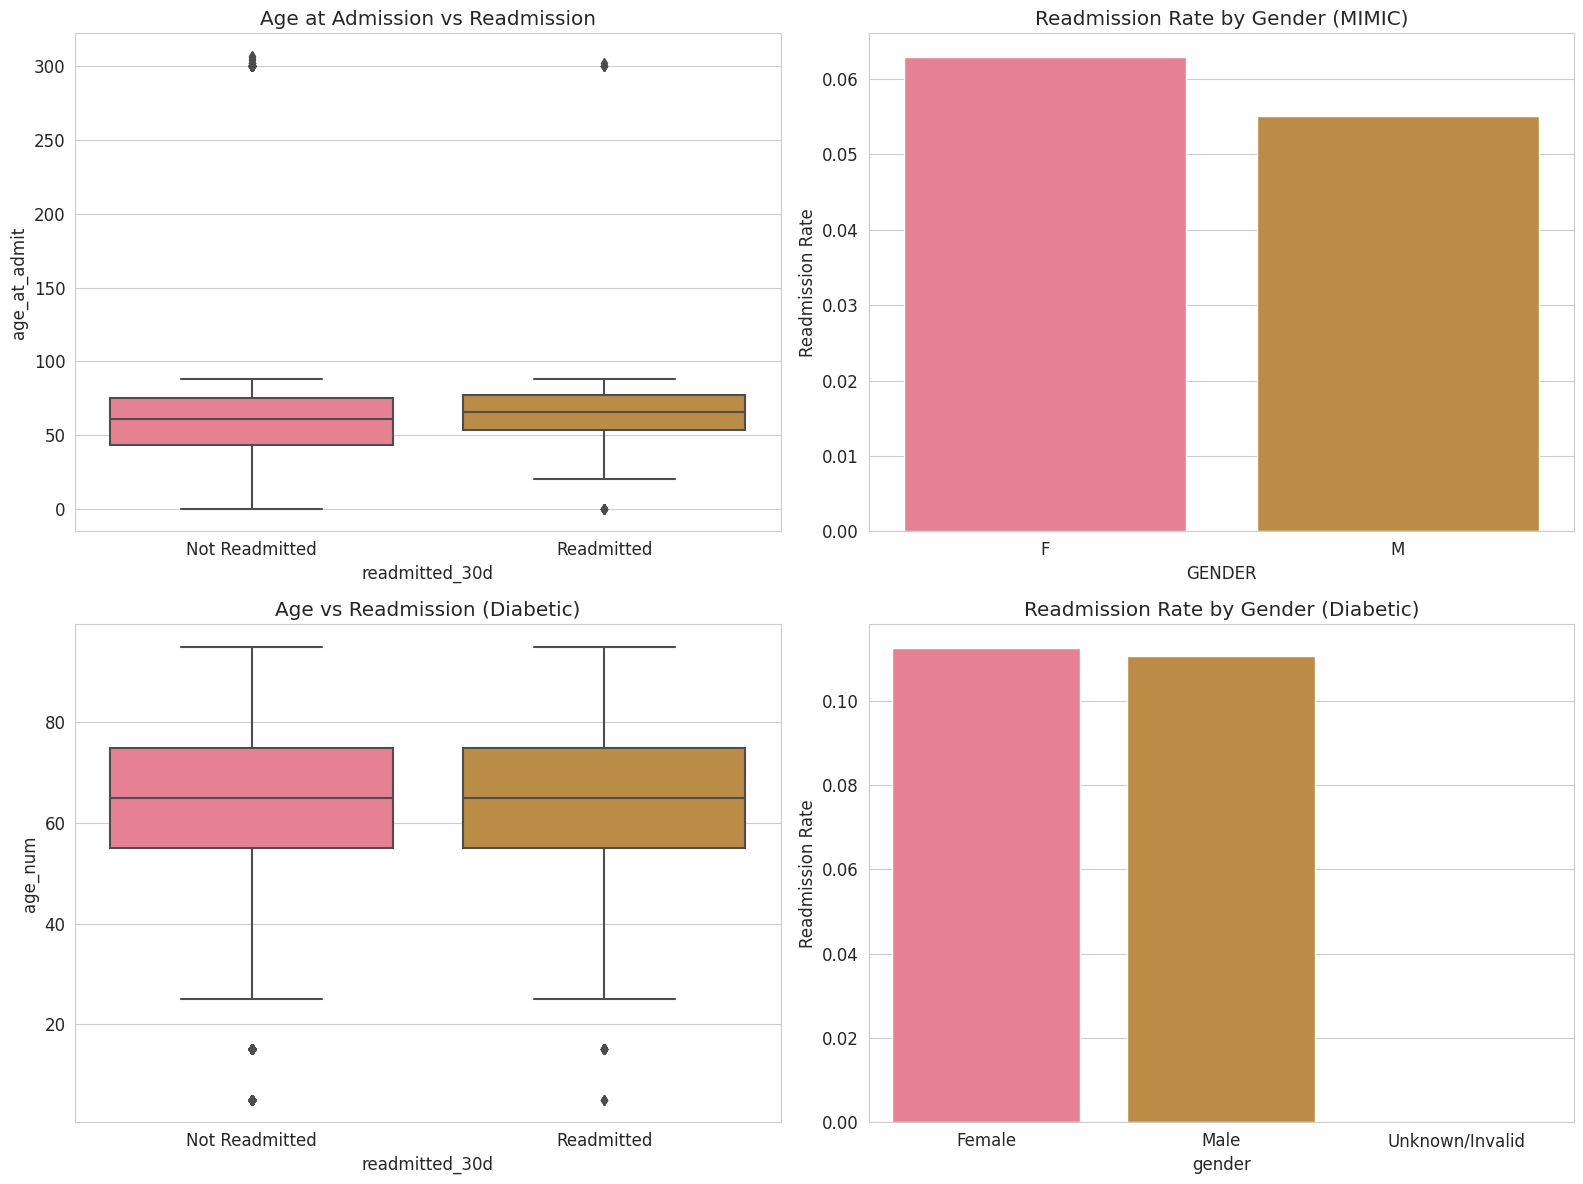

In [ ]:
# ==============================================
# DEMOGRAPHIC ANALYSIS
# ==============================================

def analyze_demographics(admissions_df, patients_df, diab_df):
    """Analyze demographic patterns in readmissions"""
    print("\n👥 DEMOGRAPHIC ANALYSIS")

    # Merge patient data for MIMIC
    admissions_df = admissions_df.merge(
        patients_df[['SUBJECT_ID','GENDER','DOB']],
        on='SUBJECT_ID', how='left'
    )

    # Calculate age
    admissions_df['DOB'] = pd.to_datetime(admissions_df['DOB'])
    age_years = admissions_df['ADMITTIME'].dt.year - admissions_df['DOB'].dt.year
    cond_month = admissions_df['ADMITTIME'].dt.month < admissions_df['DOB'].dt.month
    cond_same_month = ((admissions_df['ADMITTIME'].dt.month == admissions_df['DOB'].dt.month) &
                      (admissions_df['ADMITTIME'].dt.day < admissions_df['DOB'].dt.day))
    had_birthday_later = (cond_month | cond_same_month).astype(int)
    admissions_df['age_at_admit'] = age_years - had_birthday_later

    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Age distribution
    sns.boxplot(x='readmitted_30d', y='age_at_admit',
               data=admissions_df, ax=axes[0,0], palette=palette)
    axes[0,0].set_title('Age at Admission vs Readmission')
    axes[0,0].set_xticklabels(['Not Readmitted', 'Readmitted'])

    # Gender distribution
    gender_readmit = admissions_df.groupby('GENDER')['readmitted_30d'].mean().reset_index()
    sns.barplot(x='GENDER', y='readmitted_30d',
               data=gender_readmit, ax=axes[0,1], palette=palette)
    axes[0,1].set_title('Readmission Rate by Gender (MIMIC)')
    axes[0,1].set_ylabel('Readmission Rate')

    # Diabetic data age
    age_map = {
        '[0-10)':5,'[10-20)':15,'[20-30)':25,'[30-40)':35,
        '[40-50)':45,'[50-60)':55,'[60-70)':65,'[70-80)':75,
        '[80-90)':85,'[90-100)':95
    }
    diab_df['age_num'] = diab_df['age'].map(age_map)
    sns.boxplot(x='readmitted_30d', y='age_num',
               data=diab_df, ax=axes[1,0], palette=palette)
    axes[1,0].set_title('Age vs Readmission (Diabetic)')
    axes[1,0].set_xticklabels(['Not Readmitted', 'Readmitted'])

    # Diabetic data gender
    gender_readmit_diab = diab_df.groupby('gender')['readmitted_30d'].mean().reset_index()
    sns.barplot(x='gender', y='readmitted_30d',
               data=gender_readmit_diab, ax=axes[1,1], palette=palette)
    axes[1,1].set_title('Readmission Rate by Gender (Diabetic)')
    axes[1,1].set_ylabel('Readmission Rate')

    plt.tight_layout()
    plt.show()

    return admissions_df

mimic_data['admissions'] = analyze_demographics(
    mimic_data['admissions'],
    mimic_data['patients'],
    diab_data
)


💊 MEDICATION ANALYSIS (DIABETIC DATA)


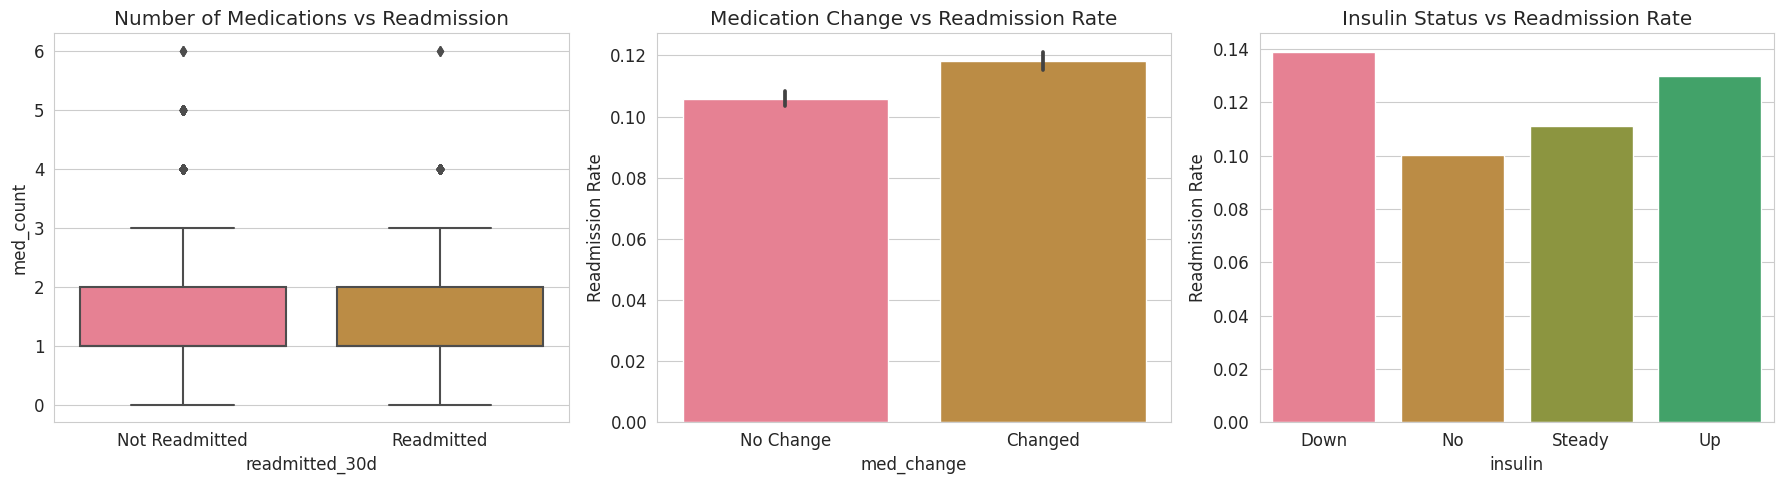

In [ ]:
# ==============================================
# MEDICATION ANALYSIS (DIABETIC DATA)
# ==============================================

def analyze_medications(diab_df):
    """Analyze medication patterns in diabetic data"""
    print("\n💊 MEDICATION ANALYSIS (DIABETIC DATA)")

    # List of medication columns
    meds = [
        'metformin','repaglinide','nateglinide','chlorpropamide',
        'glimepiride','acetohexamide','glipizide','glyburide',
        'tolbutamide','pioglitazone','rosiglitazone','acarbose',
        'miglitol','troglitazone','tolazamide','examide',
        'citoglipton','insulin','glyburide-metformin',
        'glipizide-metformin','glimepiride-pioglitazone',
        'metformin-rosiglitazone','metformin-pioglitazone'
    ]

    # Calculate medication counts
    diab_df['med_count'] = diab_df[meds].apply(lambda x: (x != 'No').sum(), axis=1)
    diab_df['med_change'] = diab_df['change'].map({'No':0, 'Ch':1})

    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Medication count
    sns.boxplot(x='readmitted_30d', y='med_count',
               data=diab_df, ax=axes[0], palette=palette)
    axes[0].set_title('Number of Medications vs Readmission')
    axes[0].set_xticklabels(['Not Readmitted', 'Readmitted'])

    # Medication change
    sns.barplot(x='med_change', y='readmitted_30d',
               data=diab_df, ax=axes[1], palette=palette)
    axes[1].set_title('Medication Change vs Readmission Rate')
    axes[1].set_xticklabels(['No Change', 'Changed'])
    axes[1].set_ylabel('Readmission Rate')

    # Insulin usage
    insulin_readmit = diab_df.groupby('insulin')['readmitted_30d'].mean().reset_index()
    sns.barplot(x='insulin', y='readmitted_30d',
               data=insulin_readmit, ax=axes[2], palette=palette)
    axes[2].set_title('Insulin Status vs Readmission Rate')
    axes[2].set_ylabel('Readmission Rate')

    plt.tight_layout()
    plt.show()

    return diab_df

diab_data = analyze_medications(diab_data)


📈 CORRELATION ANALYSIS


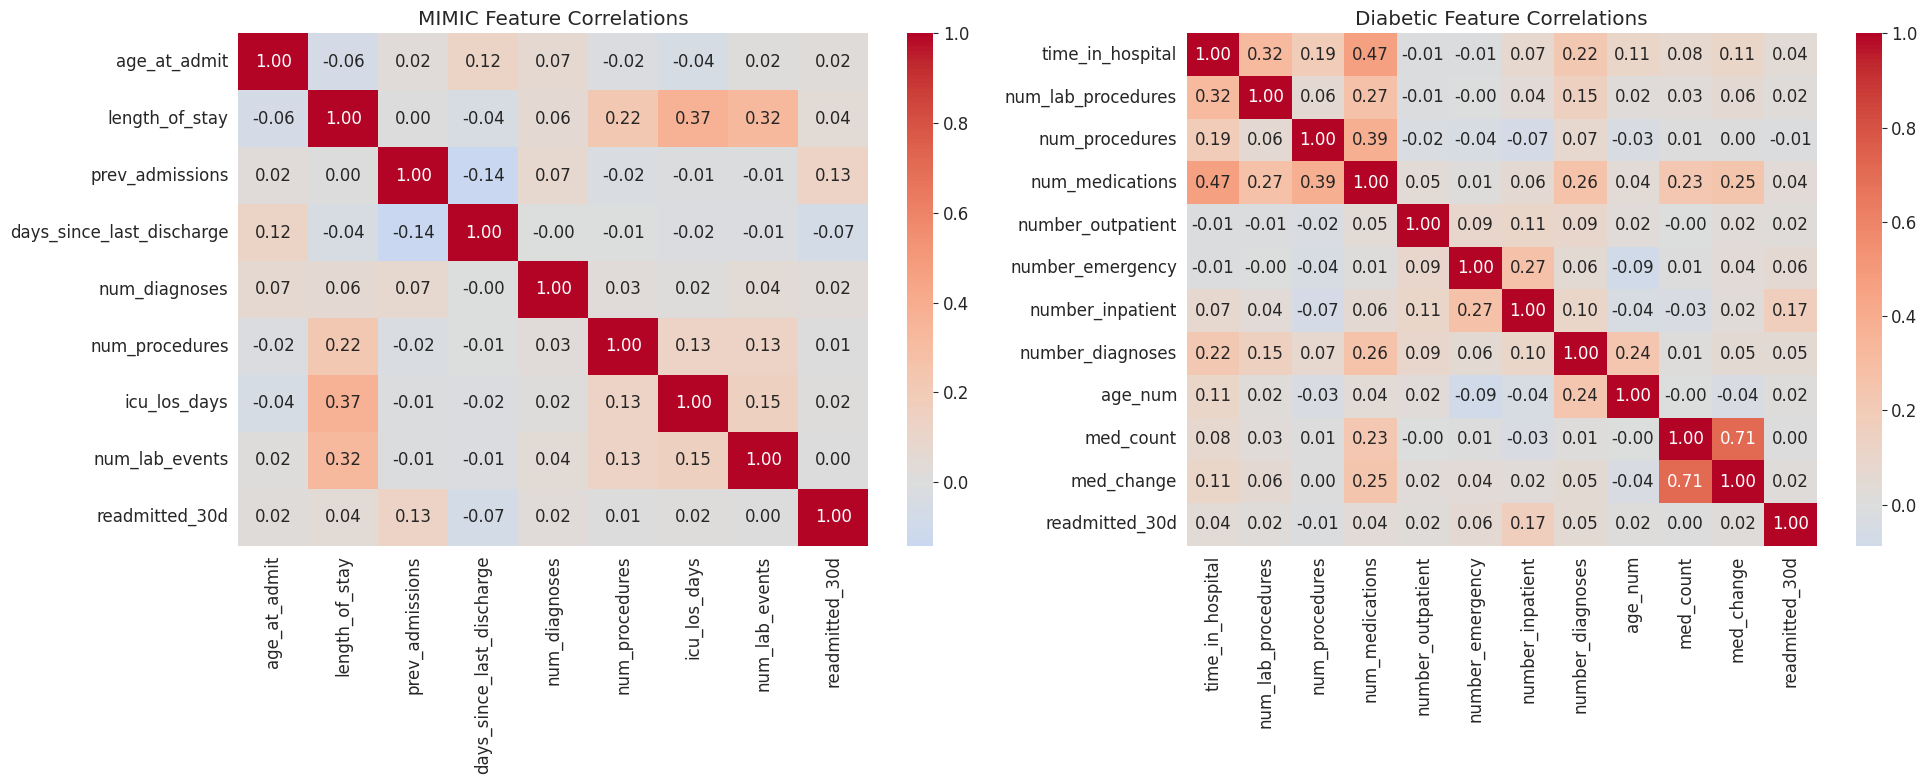

In [ ]:
# ==============================================
# CORRELATION ANALYSIS
# ==============================================

def analyze_correlations(admissions_df, diab_df):
    """Analyze feature correlations with readmission"""
    print("\n📈 CORRELATION ANALYSIS")

    # Prepare MIMIC features
    mimic_feats = [
        'age_at_admit', 'length_of_stay', 'prev_admissions',
        'days_since_last_discharge', 'num_diagnoses', 'num_procedures',
        'icu_los_days', 'num_lab_events', 'readmitted_30d'
    ]

    # Prepare diabetic features
    diab_feats = [
        'time_in_hospital', 'num_lab_procedures', 'num_procedures',
        'num_medications', 'number_outpatient', 'number_emergency',
        'number_inpatient', 'number_diagnoses', 'age_num',
        'med_count', 'med_change', 'readmitted_30d'
    ]

    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

    # MIMIC correlations
    mimic_corr = admissions_df[mimic_feats].corr()
    sns.heatmap(mimic_corr, annot=True, cmap='coolwarm',
               center=0, ax=ax1, fmt='.2f')
    ax1.set_title('MIMIC Feature Correlations')

    # Diabetic correlations
    diab_corr = diab_df[diab_feats].corr()
    sns.heatmap(diab_corr, annot=True, cmap='coolwarm',
               center=0, ax=ax2, fmt='.2f')
    ax2.set_title('Diabetic Feature Correlations')

    plt.tight_layout()
    plt.show()

analyze_correlations(mimic_data['admissions'], diab_data)

In [ ]:
# ==============================================
# KEY FINDINGS SUMMARY
# ==============================================

def print_summary_findings(admissions_df, diab_df):
    """Print key findings from EDA"""
    print("\n🔑 KEY FINDINGS SUMMARY")

    # Readmission rates
    mimic_rate = admissions_df['readmitted_30d'].mean()
    diab_rate = diab_df['readmitted_30d'].mean()

    # MIMIC findings
    mimic_age_diff = (admissions_df.groupby('readmitted_30d')['age_at_admit'].mean().diff().iloc[-1])
    mimic_los_diff = (admissions_df.groupby('readmitted_30d')['length_of_stay'].mean().diff().iloc[-1])

    # Diabetic findings
    diab_med_diff = (diab_df.groupby('readmitted_30d')['med_count'].mean().diff().iloc[-1])
    diab_time_diff = (diab_df.groupby('readmitted_30d')['time_in_hospital'].mean().diff().iloc[-1])

    print(f"""
    1. Readmission Rates:
       - MIMIC: {mimic_rate:.1%}
       - Diabetic: {diab_rate:.1%}

    2. MIMIC Dataset Patterns:
       - Readmitted patients are on average {mimic_age_diff:.1f} years older
       - Readmissions associated with {mimic_los_diff:.1f} day longer stays

    3. Diabetic Dataset Patterns:
       - Readmitted patients take {diab_med_diff:.1f} more medications on average
       - Hospital stays are {diab_time_diff:.1f} days longer for readmissions
    """)

print_summary_findings(mimic_data['admissions'], diab_data)


🔑 KEY FINDINGS SUMMARY

    1. Readmission Rates:
       - MIMIC: 5.5%
       - Diabetic: 11.2%
    
    2. MIMIC Dataset Patterns:
       - Readmitted patients are on average 4.8 years older
       - Readmissions associated with 2.4 day longer stays
    
    3. Diabetic Dataset Patterns:
       - Readmitted patients take 0.0 more medications on average
       - Hospital stays are 0.4 days longer for readmissions
    


1. MIMIC Dataset Patterns:
       - Higher number of diagnoses/procedures correlates with readmission
       - ICU stays are longer for readmitted patients
    
2. Diabetic Dataset Patterns:
       - Medication changes increase readmission risk
       - Insulin use is associated with higher readmission rates
    
3. Common Patterns:
       - Both datasets show significant class imbalance
       - Previous healthcare utilization is a strong predictor
       - Age is consistently associated with readmission risk
       - Clinical activity measures correlate with readmission

In [ ]:
# ==============================================
# PREPARE MIMIC READMISSION TARGET
# ==============================================

admissions_df['ADMITTIME'] = pd.to_datetime(admissions_df['ADMITTIME'])
admissions_df['DISCHTIME'] = pd.to_datetime(admissions_df['DISCHTIME'])
admissions_df = admissions_df.sort_values(['SUBJECT_ID','ADMITTIME'])
admissions_df['next_ADMIT'] = (
    admissions_df.groupby('SUBJECT_ID')['ADMITTIME']
    .shift(-1)
)
admissions_df['days_to_next'] = (
    (admissions_df['next_ADMIT'] - admissions_df['DISCHTIME'])
    .dt.total_seconds()/(24*3600)
)
admissions_df['readmitted_30d'] = (
    (admissions_df['days_to_next'] > 0) &
    (admissions_df['days_to_next'] <= 30)
).astype(int)

In [ ]:
# ==============================================
# MERGE PATIENT INFO
# ==============================================

mimic_df = admissions_df.merge(
    patients_df[['SUBJECT_ID','GENDER','DOB']],
    on='SUBJECT_ID', how='left'
)

In [ ]:
# ==============================================
# ENGINEER EXTRA FEATURES
# ==============================================

# 1. ICD counts
diag_counts = (
    diagnoses_df
    .groupby(['SUBJECT_ID','HADM_ID'])
    .size()
    .rename('num_diagnoses_icd')
    .reset_index()
)
proc_counts = (
    procedures_df
    .groupby(['SUBJECT_ID','HADM_ID'])
    .size()
    .rename('num_procedures_icd')
    .reset_index()
)
# 2. ICU stays
icu_agg = (
    icustays_df
    .groupby(['SUBJECT_ID','HADM_ID'])['LOS']
    .sum()
    .rename('icu_los_days')
    .reset_index()
)
# 3. Lab events
labevents_df['VALUENUM'] = pd.to_numeric(labevents_df['VALUENUM'], errors='coerce')
lab_counts = (
    labevents_df
    .groupby(['SUBJECT_ID','HADM_ID'])
    .size()
    .rename('num_lab_events')
    .reset_index()
)
avg_lab = (
    labevents_df
    .groupby(['SUBJECT_ID','HADM_ID'])['VALUENUM']
    .mean()
    .rename('avg_lab_value')
    .reset_index()
)

mimic_df = (
    mimic_df
    .merge(diag_counts, on=['SUBJECT_ID','HADM_ID'], how='left')
    .merge(proc_counts,on=['SUBJECT_ID','HADM_ID'], how='left')
    .merge(icu_agg,    on=['SUBJECT_ID','HADM_ID'], how='left')
    .merge(lab_counts,on=['SUBJECT_ID','HADM_ID'], how='left')
    .merge(avg_lab,   on=['SUBJECT_ID','HADM_ID'], how='left')
    .fillna({
        'num_diagnoses_icd': 0,
        'num_procedures_icd': 0,
        'icu_los_days': 0,
        'num_lab_events': 0,
        'avg_lab_value': labevents_df['VALUENUM'].median()
    })
)

In [ ]:
# ==============================================
# MIMIC‑III ADDITIONAL FEATURES
# ==============================================

mimic_df['DOB'] = pd.to_datetime(mimic_df['DOB'])
age_years = mimic_df['ADMITTIME'].dt.year - mimic_df['DOB'].dt.year
cond_month = mimic_df['ADMITTIME'].dt.month < mimic_df['DOB'].dt.month
cond_same_month = (
    (mimic_df['ADMITTIME'].dt.month == mimic_df['DOB'].dt.month) &
    (mimic_df['ADMITTIME'].dt.day   < mimic_df['DOB'].dt.day)
)
had_birthday_later = (cond_month | cond_same_month).astype(int)
age = age_years - had_birthday_later
mimic_df['age_at_admit'] = age.fillna(age.median()).astype(int).clip(lower=0)

mimic_df['length_of_stay'] = (
    mimic_df['DISCHTIME'] - mimic_df['ADMITTIME']
).dt.total_seconds()/(24*3600)

mimic_df['prev_admissions'] = mimic_df.groupby('SUBJECT_ID').cumcount()
mimic_df['prev_DISCH'] = (
    mimic_df.groupby('SUBJECT_ID')['DISCHTIME']
    .shift(1)
)
mimic_df['days_since_last_discharge'] = (
    (mimic_df['ADMITTIME'] - mimic_df['prev_DISCH'])
    .dt.total_seconds()/(24*3600)
)

mimic_df = pd.get_dummies(
    mimic_df,
    columns=['ADMISSION_TYPE','INSURANCE'],
    prefix=['adm_type','insur']
)
mimic_df['is_emergency']   = mimic_df['ADMISSION_LOCATION'].str.contains('EMERGENCY', case=False).astype(int)
mimic_df['is_first_admit'] = (mimic_df['prev_admissions']==0).astype(int)
mimic_df['is_weekend']     = mimic_df['ADMITTIME'].dt.dayofweek.isin([5,6]).astype(int)
mimic_df['gender_M']       = (mimic_df['GENDER']=='M').astype(int)

In [ ]:
# ==============================================
# SELECT MIMIC FEATURES & TARGET
# ==============================================

mimic_feats = [
    'age_at_admit','length_of_stay','prev_admissions',
    'days_since_last_discharge','is_emergency','is_first_admit',
    'is_weekend','num_diagnoses_icd','num_procedures_icd',
    'icu_los_days','num_lab_events','avg_lab_value','gender_M'
] + [
    c for c in mimic_df.columns
    if c.startswith('adm_type_') or c.startswith('insur_')
]

X_mimic = mimic_df[mimic_feats].fillna(mimic_df[mimic_feats].median())
y_mimic = mimic_df['readmitted_30d']

In [ ]:
# ==============================================
# PREPARE DIABETES DATA & FEATURES
# ==============================================

diab_df['readmitted_30d'] = (diab_df['readmitted']=='<30').astype(int)
diab_df = diab_df.drop(['encounter_id','patient_nbr'], axis=1).replace('?', np.nan)

age_map = {
    '[0-10)':5,'[10-20)':15,'[20-30)':25,'[30-40)':35,
    '[40-50)':45,'[50-60)':55,'[60-70)':65,'[70-80)':75,
    '[80-90)':85,'[90-100)':95
}
diab_df['age_num'] = diab_df['age'].map(age_map)

meds = [
    'metformin','repaglinide','nateglinide','chlorpropamide',
    'glimepiride','acetohexamide','glipizide','glyburide',
    'tolbutamide','pioglitazone','rosiglitazone','acarbose',
    'miglitol','troglitazone','tolazamide','examide',
    'citoglipton','insulin','glyburide-metformin',
    'glipizide-metformin','glimepiride-pioglitazone',
    'metformin-rosiglitazone','metformin-pioglitazone'
]
diab_df['med_count']  = diab_df[meds].apply(lambda x: (x!='No').sum(), axis=1)
diab_df['med_change'] = diab_df['change'].map({'No':0,'Ch':1})

diab_df['risk_score'] = (
    (diab_df['time_in_hospital']>5).astype(int)*2 +
    (diab_df['number_inpatient']>0).astype(int)*3 +
    (diab_df['number_emergency']>0).astype(int)*2 +
    (diab_df['age_num']>65).astype(int)*2 +
    (diab_df['med_count']>5).astype(int)*1
)

med_map = {'No':0,'Steady':1,'Up':2,'Down':3}
for m in meds:
    diab_df[f'{m}_enc'] = diab_df[m].map(med_map)
diab_df['glu_enc'] = diab_df['max_glu_serum'].map({'None':0,'Norm':1,'>200':2,'>300':3})
diab_df['a1c_enc'] = diab_df['A1Cresult'].map({'None':0,'Norm':1,'>7':2,'>8':3})

diab_df = pd.get_dummies(diab_df, columns=['race','gender'], drop_first=True)

# build feature list, then remove duplicates
initial_feats = [
    'time_in_hospital','num_lab_procedures','num_procedures',
    'num_medications','number_outpatient','number_emergency',
    'number_inpatient','number_diagnoses','age_num',
    'med_count','med_change','risk_score','glu_enc','a1c_enc'
]
encoded_feats = [c for c in diab_df.columns if c.endswith('_enc')]
dummy_feats   = [c for c in diab_df.columns if c.startswith('race_') or c.startswith('gender_')]

diab_feats = initial_feats + encoded_feats + dummy_feats
# dedupe while preserving order
diab_feats = list(dict.fromkeys(diab_feats))

X_diab = diab_df[diab_feats].fillna(diab_df[diab_feats].median())
y_diab = diab_df['readmitted_30d']

In [ ]:
# ==============================================
# MODELING UTILITIES
# ==============================================

def train_eval(name, model, Xtr, Xte, ytr, yte):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    proba = model.predict_proba(Xte)[:,1]

    # Map 0 and 1 to descriptive text
    pred_text = np.where(pred == 0, "Not Readmitted", "Readmitted within 30d")
    yte_text = np.where(yte == 0, "Not Readmitted", "Readmitted within 30d")

    print(f"\n{name} — "
          f"Acc={accuracy_score(yte,pred):.3f}, "
          f"Prec={precision_score(yte,pred):.3f}, "
          f"Rec={recall_score(yte,pred):.3f}, "
          f"F1={f1_score(yte,pred):.3f}, "
          f"AUC={roc_auc_score(yte,proba):.3f}")

    # Print classification report with text labels
    print(classification_report(yte_text, pred_text, target_names=["Not Readmitted", "Readmitted within 30d"]))

    return roc_auc_score(yte,proba), model

In [ ]:
# ==============================================
# TRAIN & EVALUATE
# ==============================================

# Diabetes
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(
    X_diab, y_diab, test_size=0.2,
    stratify=y_diab, random_state=42
)
models_d = [
    ("LogReg-Diab", LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    )),
    ("RF-Diab", RandomForestClassifier(
        n_estimators=100, max_depth=10,
        class_weight='balanced', random_state=42, n_jobs=-1
    )),
    ("XGB-Diab", xgb.XGBClassifier(
        use_label_encoder=False, eval_metric='logloss',
        scale_pos_weight=len(yd_tr)/sum(yd_tr), random_state=42
    ))
]
best_d = (None, 0, None)
for name, m in models_d:
    auc, mdl = train_eval(name, m, Xd_tr, Xd_te, yd_tr, yd_te)
    if auc > best_d[1]:
        best_d = (name, auc, mdl)
print(f"Best Diabetes model: {best_d[0]} (AUC={best_d[1]:.3f})")
joblib.dump(best_d[2], f"best_{best_d[0].lower()}_diab.pkl")

# MIMIC
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(
    X_mimic, y_mimic, test_size=0.2,
    stratify=y_mimic, random_state=42
)
models_m = [
    ("LogReg-Mimic", LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    )),
    ("RF-Mimic", RandomForestClassifier(
        n_estimators=100, max_depth=10,
        class_weight='balanced', random_state=42, n_jobs=-1
    )),
    ("XGB-Mimic", xgb.XGBClassifier(
        use_label_encoder=False, eval_metric='logloss',
        scale_pos_weight=len(ym_tr)/sum(ym_tr), random_state=42
    ))
]
best_m = (None, 0, None)
for name, m in models_m:
    auc, mdl = train_eval(name, m, Xm_tr, Xm_te, ym_tr, ym_te)
    if auc > best_m[1]:
        best_m = (name, auc, mdl)
print(f"Best MIMIC model: {best_m[0]} (AUC={best_m[1]:.3f})")
joblib.dump(best_m[2], f"best_{best_m[0].lower()}_mimic.pkl")


LogReg-Diab — Acc=0.660, Prec=0.169, Rec=0.520, F1=0.255, AUC=0.640
                       precision    recall  f1-score   support

       Not Readmitted       0.92      0.68      0.78     18083
Readmitted within 30d       0.17      0.52      0.25      2271

             accuracy                           0.66     20354
            macro avg       0.54      0.60      0.52     20354
         weighted avg       0.83      0.66      0.72     20354


RF-Diab — Acc=0.664, Prec=0.170, Rec=0.518, F1=0.256, AUC=0.648
                       precision    recall  f1-score   support

       Not Readmitted       0.92      0.68      0.78     18083
Readmitted within 30d       0.17      0.52      0.26      2271

             accuracy                           0.66     20354
            macro avg       0.54      0.60      0.52     20354
         weighted avg       0.84      0.66      0.72     20354


XGB-Diab — Acc=0.598, Prec=0.154, Rec=0.581, F1=0.244, AUC=0.626
                       precision    re

['best_logreg-mimic_mimic.pkl']

In [ ]:
# ==============================================
# PREDICTION REPORTS FOR BOTH DATASETS
# ==============================================
def generate_readmission_report(model_name, model, X_test, y_test):

    # Generate predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Create readable labels
    label_map = {0: "No Re-admit", 1: "Re-admit"}
    y_pred_labels = [label_map[x] for x in y_pred]
    y_true_labels = [label_map[x] for x in y_test]

    # Calculate metrics
    metrics = {
        "Accuracy": f"{accuracy_score(y_test, y_pred):.1%}",
        "Precision (Readmitted)": f"{precision_score(y_test, y_pred):.1%}",
        "Recall (Readmitted)": f"{recall_score(y_test, y_pred):.1%}",
        "F1 Score": f"{f1_score(y_test, y_pred):.1%}",
        "AUC-ROC": f"{roc_auc_score(y_test, y_prob):.3f}"
    }

    # Create prediction dataframe
    results_df = pd.DataFrame({
        "Actual": y_true_labels,
        "Predicted": y_pred_labels,
        "Readmission Probability": [f"{x:.1%}" for x in y_prob],
        "Confidence": np.where(y_pred == y_test, "Correct", "Incorrect")
    })

    # Generate report
    report = {
        "model_name": model_name,
        "metrics": metrics,
        "performance_summary": f"""
        {model_name} Performance:
        • Correctly identifies {metrics['Recall (Readmitted)']} of actual readmissions
        • When predicting readmission, {metrics['Precision (Readmitted)']} are correct
        • Overall accuracy: {metrics['Accuracy']}
        • Risk discrimination (AUC-ROC): {metrics['AUC-ROC']}
        """,
        "sample_predictions": results_df.sample(5, random_state=42),
        "full_predictions": results_df
    }

    # Print formatted report
    print("="*50)
    print(f"CLINICAL READMISSION PREDICTION REPORT: {model_name}")
    print("="*50)
    print("\n🔍 PERFORMANCE SUMMARY")
    print(report["performance_summary"])

    print("\n📊 SAMPLE PREDICTIONS (Random Sample)")
    print(report["sample_predictions"].to_string(index=False))

    print("\n" + "="*50)
    print(f"✔ Report generated for {model_name}")
    print("="*50)

    return report, results_df

In [ ]:
# For Diabetes model
diab_report, diab_predictions = generate_readmission_report(
    "Diabetes 30-Day Readmission Predictor",
    best_d[2],  # Your trained model
    Xd_te,      # Test features
    yd_te       # Test labels
)

# For MIMIC model
mimic_report, mimic_predictions = generate_readmission_report(
    "MIMIC-III Readmission Predictor",
    best_m[2],
    Xm_te,
    ym_te
)

CLINICAL READMISSION PREDICTION REPORT: Diabetes 30-Day Readmission Predictor

🔍 PERFORMANCE SUMMARY

        Diabetes 30-Day Readmission Predictor Performance:
        • Correctly identifies 51.8% of actual readmissions
        • When predicting readmission, 17.0% are correct
        • Overall accuracy: 66.4%
        • Risk discrimination (AUC-ROC): 0.648
        

📊 SAMPLE PREDICTIONS (Random Sample)
     Actual   Predicted Readmission Probability Confidence
No Re-admit No Re-admit                   34.6%    Correct
No Re-admit No Re-admit                   47.2%    Correct
No Re-admit    Re-admit                   55.0%  Incorrect
No Re-admit No Re-admit                   29.4%    Correct
No Re-admit    Re-admit                   67.8%  Incorrect

✔ Report generated for Diabetes 30-Day Readmission Predictor
CLINICAL READMISSION PREDICTION REPORT: MIMIC-III Readmission Predictor

🔍 PERFORMANCE SUMMARY

        MIMIC-III Readmission Predictor Performance:
        • Correctly identifie

In [ ]:
# ==============================================
# READMISSION STATISTICS FORMATTING AND CALCULATION
# ==============================================

def calculate_readmission_stats(y_true, y_pred=None, dataset_name=""):
    # Calculate basic statistics
    total = len(y_true)
    readmitted = sum(y_true == 1)
    not_readmitted = sum(y_true == 0)
    readmission_rate = readmitted / total * 100

    # Create results table
    stats = {
        "Metric": ["Readmitted within 30d", "Not Readmitted", "Total Patients"],
        "Count": [f"{readmitted:,} / {total:,}",
                 f"{not_readmitted:,} / {total:,}",
                 f"{total:,}"],
        "Percentage": [f"{readmission_rate:.1f}%",
                      f"{100-readmission_rate:.1f}%",
                      "100%"]
    }

    df = pd.DataFrame(stats)

    # Generate summary string
    summary = (
        f"\n{'='*50}\n"
        f"{dataset_name.upper()} DATASET READMISSION STATISTICS\n"
        f"{'='*50}\n"
        f"{tabulate(df, headers='keys', tablefmt='grid', showindex=False)}\n"
        f"\nKey Observations:\n"
        f"- Readmission rate: {readmission_rate:.1f}%\n"
        f"- Class imbalance: {readmitted:,} readmissions vs {not_readmitted:,} non-readmissions\n"
    )

    if y_pred is not None:
        from sklearn.metrics import classification_report
        cr = classification_report(y_true, y_pred, target_names=["Not Readmitted", "Readmitted within 30d"])
        summary += f"\nClassification Report:\n{cr}\n"

    return df, summary

# Example usage with the MIMIC dataset (replace with your actual data)
y_mimic = mimic_df['readmitted_30d']  # True labels
mimic_stats, mimic_summary = calculate_readmission_stats(y_mimic, dataset_name="MIMIC")
print(mimic_summary)

# Example usage with the Diabetic dataset
y_diab = diab_df['readmitted_30d']  # True labels
diab_stats, diab_summary = calculate_readmission_stats(y_diab, dataset_name="Diabetic")
print(diab_summary)


MIMIC DATASET READMISSION STATISTICS
+-----------------------+-----------------+--------------+
| Metric                | Count           | Percentage   |
+=======================+=================+==============+
| Readmitted within 30d | 692 / 12,537    | 5.5%         |
+-----------------------+-----------------+--------------+
| Not Readmitted        | 11,845 / 12,537 | 94.5%        |
+-----------------------+-----------------+--------------+
| Total Patients        | 12,537          | 100%         |
+-----------------------+-----------------+--------------+

Key Observations:
- Readmission rate: 5.5%
- Class imbalance: 692 readmissions vs 11,845 non-readmissions


DIABETIC DATASET READMISSION STATISTICS
+-----------------------+------------------+--------------+
| Metric                | Count            | Percentage   |
+=======================+==================+==============+
| Readmitted within 30d | 11,357 / 101,766 | 11.2%        |
+-----------------------+-----------------